# LSTM Direction Classifier - Multi-Horizon Analysis

**Goal**: Predict market direction (UP/FLAT/DOWN) for multiple time horizons

**Key Features**:
- Multi-task learning: Predict 1-day, 3-day, 5-day, and 10-day simultaneously
- Absolute predictions: All based on current day (day 0)
- Market regime clustering: Adds context about current market conditions
- Signal strength: When all horizons agree, strong signal!

**Model**: LSTM with 4 output heads, trained on OHLCV + RSI + ClusterID

## Part 1: Setup

### 1.1 Import Libraries

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Import custom modules
from LSTM_Direction_Classifier import LSTMDirectionClassifier
from Data_Handling import get_data_auto

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

print("✓ Libraries imported successfully")
print(f"📅 Analysis Date: {datetime.now().strftime('%Y-%m-%d')}")

✓ Libraries imported successfully
📅 Analysis Date: 2026-01-20


### 1.2 Configuration

In [21]:
# Data parameters
SYMBOL = "SPY"
TIMEFRAME_UNIT = "Day"
MULTIPLIER = 1

# Time periods - EXPANDED for more robust training and testing
TRAIN_START = "2018-01-01"  # Extended from 2022 to get 4 more years of data
TRAIN_END = "2024-09-30"
TEST_START = "2024-10-01"
TEST_END = "2025-12-31"  # Extended to get more test samples

# Model configuration
LOOKBACK_WINDOW = 60
PREDICTION_HORIZONS = [1, 3, 5, 10]  # Predict multiple horizons
LSTM_UNITS = 64
NUM_LAYERS = 2
DROPOUT = 0.3
N_CLUSTERS = 3  # Market regime clusters (added as input feature)

# Training parameters
EPOCHS = 50
BATCH_SIZE = 32
LEARNING_RATE = 0.001

print("="*80)
print("DIRECTION CLASSIFIER CONFIGURATION")
print("="*80)
print(f"\n📊 Data:")
print(f"   Symbol: {SYMBOL}")
print(f"   Training: {TRAIN_START} → {TRAIN_END}")
print(f"   Testing: {TEST_START} → {TEST_END}")
print(f"\n🎯 Prediction:")
print(f"   Horizons: {PREDICTION_HORIZONS} days")
print(f"   Classes: UP, FLAT, DOWN")
print(f"   Strategy: Absolute (all from day 0)")
print(f"\n🏗️  Architecture:")
print(f"   Lookback: {LOOKBACK_WINDOW} days")
print(f"   LSTM: {NUM_LAYERS} layers × {LSTM_UNITS} units")
print(f"   Features: 7 (OHLCV returns + RSI + cluster_id)")
print(f"   Market regimes: {N_CLUSTERS} clusters (as input feature)")
print("="*80)

DIRECTION CLASSIFIER CONFIGURATION

📊 Data:
   Symbol: SPY
   Training: 2018-01-01 → 2024-09-30
   Testing: 2024-10-01 → 2025-12-31

🎯 Prediction:
   Horizons: [1, 3, 5, 10] days
   Classes: UP, FLAT, DOWN
   Strategy: Absolute (all from day 0)

🏗️  Architecture:
   Lookback: 60 days
   LSTM: 2 layers × 64 units
   Features: 7 (OHLCV returns + RSI + cluster_id)
   Market regimes: 3 clusters (as input feature)


## Part 2: Load Data

In [22]:
print("Loading training data...")
train_data = get_data_auto(
    symbol=SYMBOL,
    start=TRAIN_START,
    end=TRAIN_END,
    timeframe_unit=TIMEFRAME_UNIT,
    multiplier=MULTIPLIER
)

print("Loading test data...")
test_data = get_data_auto(
    symbol=SYMBOL,
    start=TEST_START,
    end=TEST_END,
    timeframe_unit=TIMEFRAME_UNIT,
    multiplier=MULTIPLIER
)

print("\n" + "="*80)
print("DATA LOADED")
print("="*80)
print(f"\n📈 Training: {len(train_data)} days ({train_data.index[0].date()} → {train_data.index[-1].date()})")
print(f"📊 Testing: {len(test_data)} days ({test_data.index[0].date()} → {test_data.index[-1].date()})")
print(f"\n🔢 Features: {list(train_data.columns)}")
print("="*80)

Loading training data...
Loading test data...

DATA LOADED

📈 Training: 1696 days (2018-01-02 → 2024-09-27)
📊 Testing: 313 days (2024-10-01 → 2025-12-30)

🔢 Features: ['Open', 'High', 'Low', 'Close', 'Volume']


## Part 3: Train Model

In [23]:
# Initialize classifier
classifier = LSTMDirectionClassifier(
    lookback_window=LOOKBACK_WINDOW,
    prediction_horizons=PREDICTION_HORIZONS,
    lstm_units=LSTM_UNITS,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    n_clusters=N_CLUSTERS,
    verbose=1
)

# Train model
history = classifier.fit(
    train_data,
    validation_split=0.2,
    early_stopping_patience=10
)

print("\n" + "="*80)
print("✓ TRAINING COMPLETE")
print("="*80)

TRAINING LSTM DIRECTION CLASSIFIER

📊 Data: 1696 samples
🎯 Prediction horizons: [1, 3, 5, 10] days
🏗️  Lookback window: 60 days
🔧 Architecture: 2 LSTM layers × 64 units
📈 Classes: ['DOWN', 'FLAT', 'UP']
🎲 Market regimes: 3 clusters

✓ Fitted 3 market regime clusters
  Cluster distribution: {0: 1080, 1: 591, 2: 25}

📦 Training data shape:
   X: (1627, 60, 7)
   y_1day: (1627,)
   y_3day: (1627,)
   y_5day: (1627,)
   y_10day: (1627,)

📊 Class distributions:
   1-day: {'DOWN': 392, 'FLAT': 731, 'UP': 504}
   3-day: {'DOWN': 333, 'FLAT': 786, 'UP': 508}
   5-day: {'DOWN': 287, 'FLAT': 870, 'UP': 470}
   10-day: {'DOWN': 293, 'FLAT': 785, 'UP': 549}

🏗️  Model architecture:


Model: "LSTM_Direction_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 60, 7)     │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 60, 64)    │     18,432 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 60, 64)    │          0 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 64)        │     33,024 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_dense        │ (None, 32)        │      2,080 │ dropout_2[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_1day (Dense) │ (None, 3)         │         99 │ shared_dense[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_3day (Dense) │ (None, 3)         │         99 │ shared_dense[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_5day (Dense) │ (None, 3)         │         99 │ shared_dense[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_10day        │ (None, 3)         │         99 │ shared_dense[0][… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 53,932 (210.67 KB)

 Trainable params: 53,932 (210.67 KB)

 Non-trainable params: 0 (0.00 B)


🚀 Starting training...
Epoch 1/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 9s 95ms/step - loss: 4.2488 - output_10day_accuracy: 0.4950 - output_10day_loss: 1.0593 - output_1day_accuracy: 0.4274 - output_1day_loss: 1.0771 - output_3day_accuracy: 0.4350 - output_3day_loss: 1.0647 - output_5day_accuracy: 0.4796 - output_5day_loss: 1.0475 - val_loss: 4.1113 - val_output_10day_accuracy: 0.5092 - val_output_10day_loss: 1.0705 - val_output_1day_accuracy: 0.4785 - val_output_1day_loss: 1.0521 - val_output_3day_accuracy: 0.5092 - val_output_3day_loss: 1.0114 - val_output_5day_accuracy: 0.5337 - val_output_5day_loss: 0.9883
Epoch 2/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - loss: 4.0602 - output_10day_accuracy: 0.5388 - output_10day_loss: 1.0046 - output_1day_accuracy: 0.4620 - output_1day_loss: 1.0522 - output_3day_accuracy: 0.4958 - output_3day_loss: 1.0197 - output_5day_accuracy: 0.5457 - output_5day_loss: 0.9830 - val_loss: 3.9799 - val_output_10day_accuracy: 0.5153 - val_output_10day_loss: 1.0453 - va

### 3.1 Training History

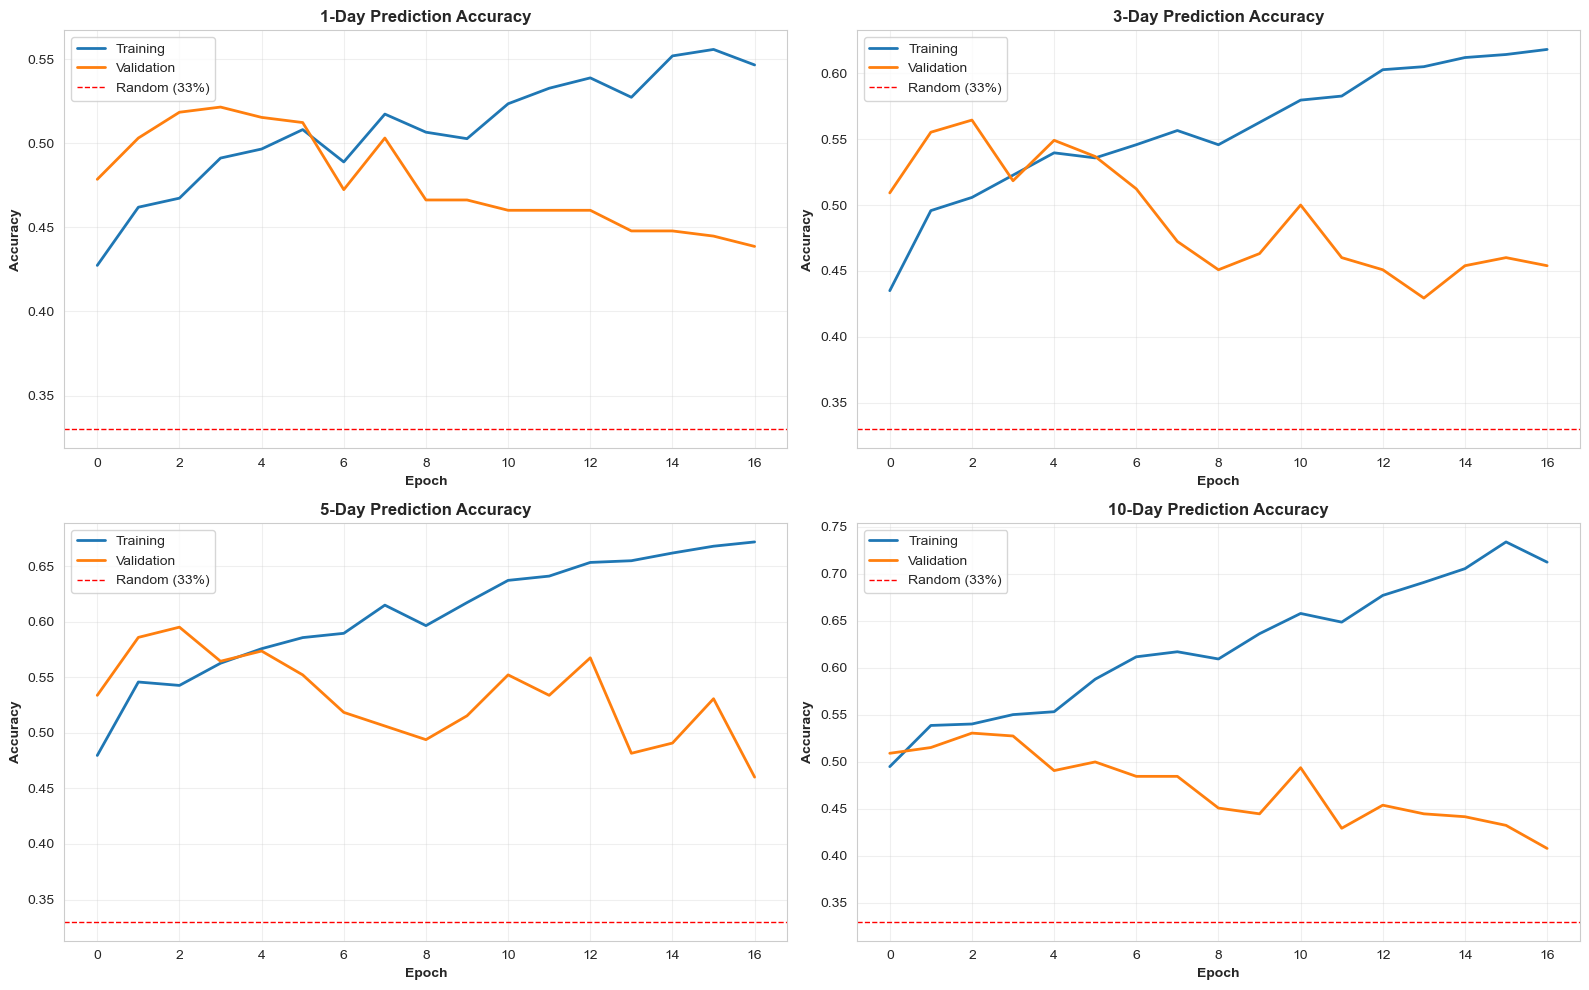


Final Training Accuracies:
  1-day: Train=0.547, Val=0.439
  3-day: Train=0.618, Val=0.454
  5-day: Train=0.672, Val=0.460
  10-day: Train=0.713, Val=0.408


In [24]:
# Plot training history for each output head
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, horizon in enumerate(PREDICTION_HORIZONS):
    ax = axes[i]
    
    # Plot accuracy
    train_acc_key = f'output_{horizon}day_accuracy'
    val_acc_key = f'val_output_{horizon}day_accuracy'
    
    ax.plot(history.history[train_acc_key], label='Training', linewidth=2)
    ax.plot(history.history[val_acc_key], label='Validation', linewidth=2)
    ax.axhline(y=0.33, color='red', linestyle='--', linewidth=1, label='Random (33%)')
    
    ax.set_title(f'{horizon}-Day Prediction Accuracy', fontweight='bold', fontsize=12)
    ax.set_xlabel('Epoch', fontweight='bold')
    ax.set_ylabel('Accuracy', fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print final accuracies
print("\nFinal Training Accuracies:")
for horizon in PREDICTION_HORIZONS:
    train_key = f'output_{horizon}day_accuracy'
    val_key = f'val_output_{horizon}day_accuracy'
    print(f"  {horizon}-day: Train={history.history[train_key][-1]:.3f}, Val={history.history[val_key][-1]:.3f}")

## Part 4: Generate Predictions

In [25]:
print("="*80)
print("GENERATING PREDICTIONS ON TEST DATA")
print("="*80)

# Get predictions with probabilities
predictions = classifier.predict(test_data, return_probabilities=True)

print(f"\n✓ Predictions generated for {len(predictions)} test samples")
print(f"\nColumns: {list(predictions.columns)}")

# Show sample predictions
print("\nSample predictions (first 10):")
display_cols = ['actual_close', 'cluster_id'] + [f'pred_{h}day' for h in PREDICTION_HORIZONS]
print(predictions[display_cols].head(10).to_string())

GENERATING PREDICTIONS ON TEST DATA

✓ Predictions generated for 244 test samples

Columns: ['actual_close', 'cluster_id', 'pred_1day_DOWN', 'pred_1day_FLAT', 'pred_1day_UP', 'pred_1day', 'confidence_1day', 'pred_3day_DOWN', 'pred_3day_FLAT', 'pred_3day_UP', 'pred_3day', 'confidence_3day', 'pred_5day_DOWN', 'pred_5day_FLAT', 'pred_5day_UP', 'pred_5day', 'confidence_5day', 'pred_10day_DOWN', 'pred_10day_FLAT', 'pred_10day_UP', 'pred_10day', 'confidence_10day']

Sample predictions (first 10):
                           actual_close  cluster_id pred_1day pred_3day pred_5day pred_10day
timestamp                                                                                   
2024-12-26 05:00:00+00:00    594.360352           1        UP      DOWN      FLAT       FLAT
2024-12-27 05:00:00+00:00    588.103821           1        UP      DOWN      FLAT       FLAT
2024-12-30 05:00:00+00:00    581.392578           1        UP      DOWN      FLAT       FLAT
2024-12-31 05:00:00+00:00    579.277466

## Part 5: Evaluate Performance

TEST SET PERFORMANCE

📊 Accuracy by Horizon:
   1-day: 0.533 (53.3%) on 244 samples
   3-day: 0.533 (53.3%) on 244 samples
   5-day: 0.549 (54.9%) on 244 samples
   10-day: 0.582 (58.2%) on 244 samples


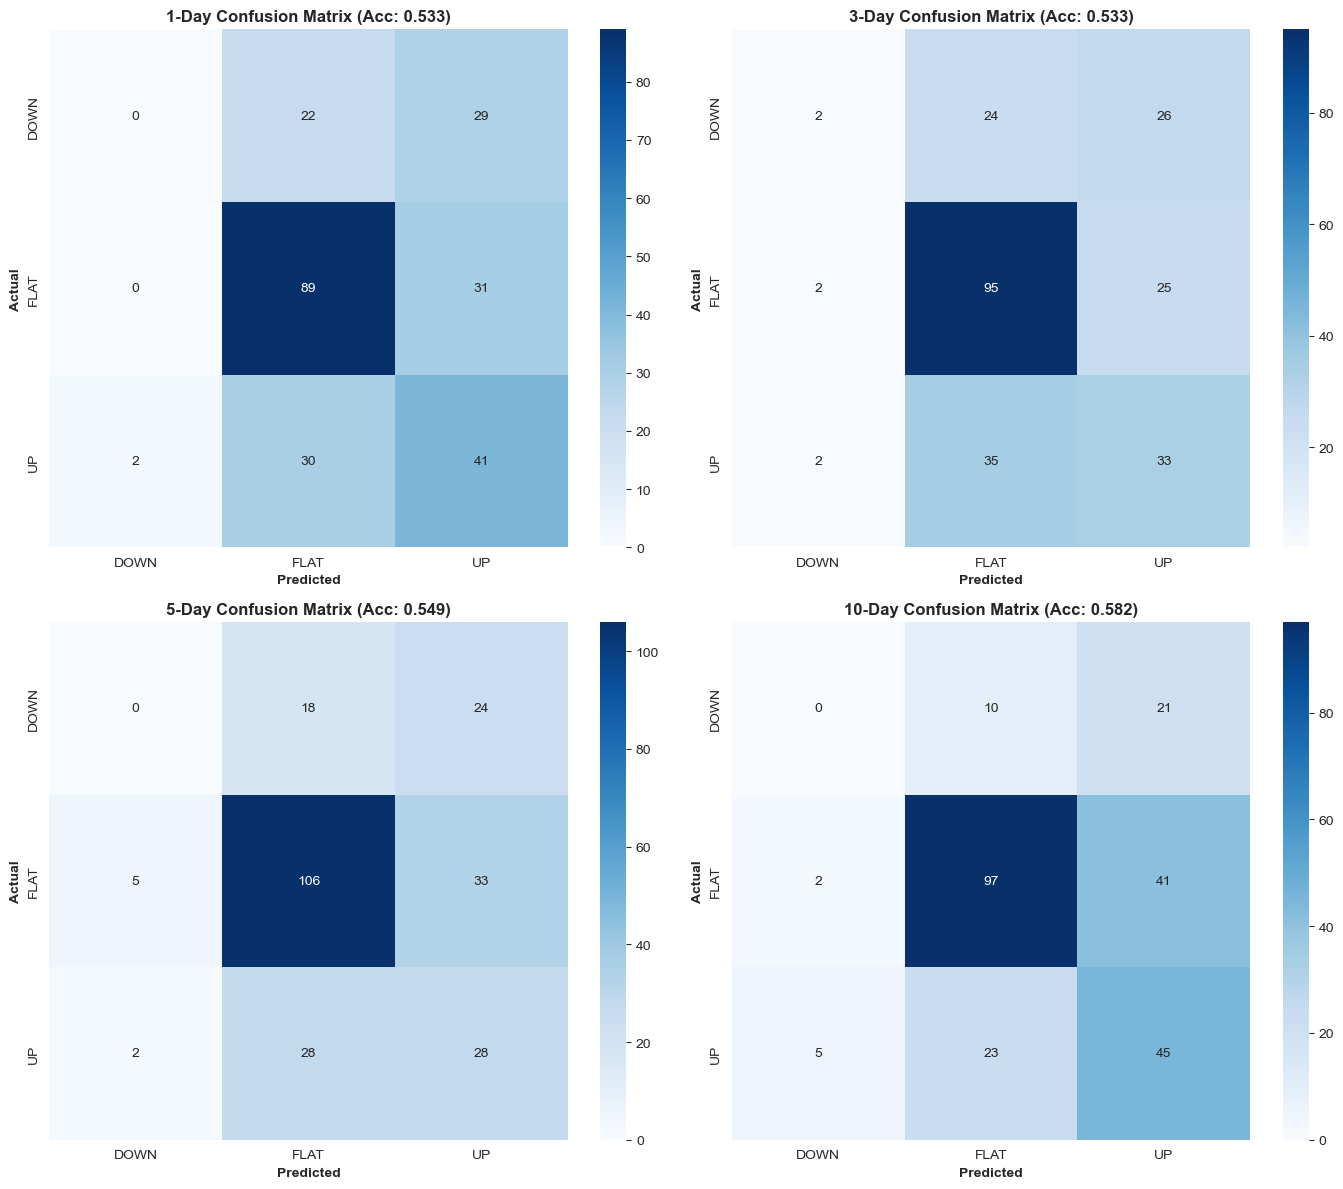

In [26]:
# Evaluate on test data
metrics, predictions = classifier.evaluate(test_data)

print("="*80)
print("TEST SET PERFORMANCE")
print("="*80)

# Print accuracies
print("\n📊 Accuracy by Horizon:")
for horizon in PREDICTION_HORIZONS:
    acc = metrics[horizon]['accuracy']
    n = metrics[horizon]['n_samples']
    print(f"   {horizon}-day: {acc:.3f} ({acc*100:.1f}%) on {n} samples")

# Plot confusion matrices
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for i, horizon in enumerate(PREDICTION_HORIZONS):
    ax = axes[i]
    cm = metrics[horizon]['confusion_matrix']
    
    # Plot heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['DOWN', 'FLAT', 'UP'],
                yticklabels=['DOWN', 'FLAT', 'UP'])
    
    ax.set_title(f'{horizon}-Day Confusion Matrix (Acc: {metrics[horizon]["accuracy"]:.3f})',
                 fontweight='bold', fontsize=12)
    ax.set_xlabel('Predicted', fontweight='bold')
    ax.set_ylabel('Actual', fontweight='bold')

plt.tight_layout()
plt.show()

## Part 6: Signal Strength Analysis

### 6.1 Multi-Horizon Agreement

When multiple horizons agree, the signal is STRONGER!

SIGNAL STRENGTH ANALYSIS

How often do all horizons agree?

All agree UP:     77 ( 31.6%)
All agree FLAT:  123 ( 50.4%)
All agree DOWN:    0 (  0.0%)
Mixed signals:    44 ( 18.0%)


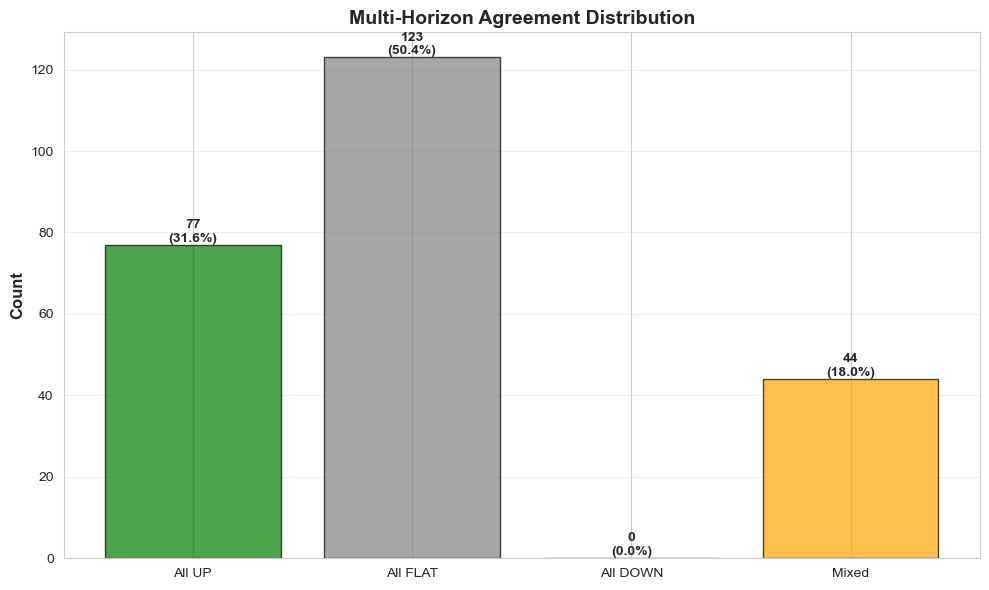

In [27]:
print("="*80)
print("SIGNAL STRENGTH ANALYSIS")
print("="*80)
print("\nHow often do all horizons agree?\n")

# Check agreement across all horizons
pred_cols = [f'pred_{h}day' for h in PREDICTION_HORIZONS]

# Count when all agree
all_up = (predictions[pred_cols] == 'UP').all(axis=1).sum()
all_flat = (predictions[pred_cols] == 'FLAT').all(axis=1).sum()
all_down = (predictions[pred_cols] == 'DOWN').all(axis=1).sum()
mixed = len(predictions) - all_up - all_flat - all_down

print(f"All agree UP:   {all_up:4d} ({all_up/len(predictions)*100:5.1f}%)")
print(f"All agree FLAT: {all_flat:4d} ({all_flat/len(predictions)*100:5.1f}%)")
print(f"All agree DOWN: {all_down:4d} ({all_down/len(predictions)*100:5.1f}%)")
print(f"Mixed signals:  {mixed:4d} ({mixed/len(predictions)*100:5.1f}%)")

# Visualize
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
categories = ['All UP', 'All FLAT', 'All DOWN', 'Mixed']
counts = [all_up, all_flat, all_down, mixed]
colors = ['green', 'gray', 'red', 'orange']

bars = ax.bar(categories, counts, color=colors, alpha=0.7, edgecolor='black')
ax.set_ylabel('Count', fontweight='bold', fontsize=12)
ax.set_title('Multi-Horizon Agreement Distribution', fontweight='bold', fontsize=14)
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, count in zip(bars, counts):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{count}\n({count/len(predictions)*100:.1f}%)',
            ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

### 6.2 Confidence-Based Trading Strategy

**Idea**: Only trade when ALL horizons agree (strong signal)

In [28]:
print("="*80)
print("CONFIDENCE-BASED TRADING STRATEGY")
print("="*80)
print("\nStrategy: Only trade when ALL horizons agree\n")

# Add agreement column
predictions['all_agree_UP'] = (predictions[pred_cols] == 'UP').all(axis=1)
predictions['all_agree_DOWN'] = (predictions[pred_cols] == 'DOWN').all(axis=1)
predictions['all_agree_FLAT'] = (predictions[pred_cols] == 'FLAT').all(axis=1)

# Calculate actual future returns for each horizon
for horizon in PREDICTION_HORIZONS:
    predictions[f'actual_return_{horizon}day'] = predictions['actual_close'].pct_change(horizon).shift(-horizon) * 100

# Evaluate trading performance
print("Performance when ALL horizons agree:\n")

for signal_type in ['UP', 'DOWN']:
    signal_col = f'all_agree_{signal_type}'
    signals = predictions[predictions[signal_col]].copy()
    
    if len(signals) == 0:
        continue
    
    print(f"\n{signal_type} Signals: {len(signals)} occurrences")
    
    for horizon in PREDICTION_HORIZONS:
        return_col = f'actual_return_{horizon}day'
        valid_returns = signals[return_col].dropna()
        
        if len(valid_returns) == 0:
            continue
        
        avg_return = valid_returns.mean()
        win_rate = (valid_returns > 0).mean() * 100 if signal_type == 'UP' else (valid_returns < 0).mean() * 100
        
        print(f"  {horizon}-day: Avg Return={avg_return:+.2f}%, Win Rate={win_rate:.1f}%")

print("\n" + "="*80)
print("✓ Strong signals (all horizons agree) should have better win rates!")
print("="*80)

CONFIDENCE-BASED TRADING STRATEGY

Strategy: Only trade when ALL horizons agree

Performance when ALL horizons agree:


UP Signals: 77 occurrences
  1-day: Avg Return=+0.07%, Win Rate=61.0%
  3-day: Avg Return=+0.20%, Win Rate=54.5%
  5-day: Avg Return=+0.37%, Win Rate=62.3%
  10-day: Avg Return=+0.76%, Win Rate=63.6%

✓ Strong signals (all horizons agree) should have better win rates!


## Part 7: Market Regime Analysis

MARKET REGIME CLUSTERING

3 clusters identified

Cluster distribution:
  Cluster 0: 161 samples (66.0%)
  Cluster 1: 80 samples (32.8%)
  Cluster 2: 3 samples (1.2%)

Prediction tendencies by cluster (1-day):

  Cluster 0:
    UP: 16.8%
    FLAT: 83.2%

  Cluster 1:
    UP: 88.8%
    FLAT: 8.8%
    DOWN: 2.5%

  Cluster 2:
    UP: 100.0%


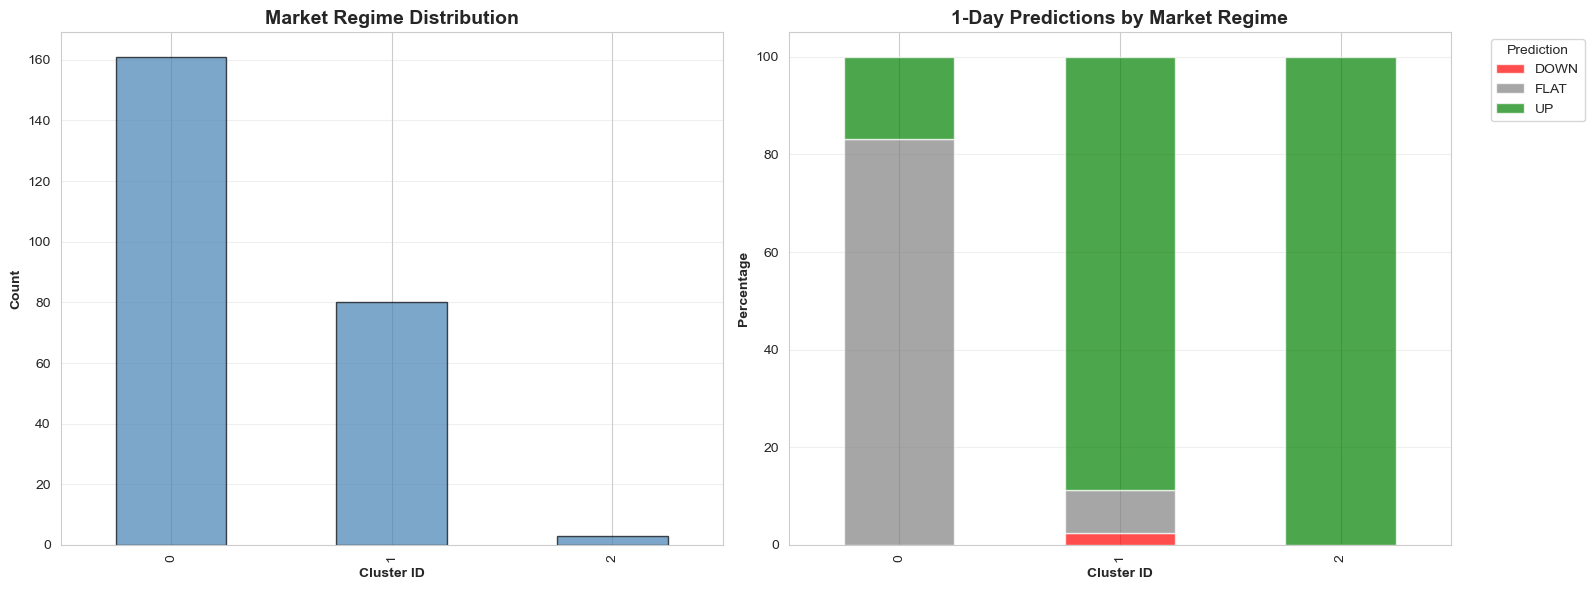

In [29]:
print("="*80)
print("MARKET REGIME CLUSTERING")
print("="*80)
print(f"\n{N_CLUSTERS} clusters identified\n")

# Analyze cluster characteristics
print("Cluster distribution:")
cluster_counts = predictions['cluster_id'].value_counts().sort_index()
for cluster_id, count in cluster_counts.items():
    print(f"  Cluster {cluster_id}: {count} samples ({count/len(predictions)*100:.1f}%)")

# Analyze prediction distribution by cluster
print("\nPrediction tendencies by cluster (1-day):")
for cluster_id in range(N_CLUSTERS):
    cluster_data = predictions[predictions['cluster_id'] == cluster_id]
    if len(cluster_data) == 0:
        continue
    
    pred_dist = cluster_data['pred_1day'].value_counts(normalize=True) * 100
    print(f"\n  Cluster {cluster_id}:")
    for direction in ['UP', 'FLAT', 'DOWN']:
        if direction in pred_dist:
            print(f"    {direction}: {pred_dist[direction]:.1f}%")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Cluster distribution
ax1 = axes[0]
cluster_counts.plot(kind='bar', ax=ax1, color='steelblue', alpha=0.7, edgecolor='black')
ax1.set_title('Market Regime Distribution', fontweight='bold', fontsize=14)
ax1.set_xlabel('Cluster ID', fontweight='bold')
ax1.set_ylabel('Count', fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Prediction by cluster
ax2 = axes[1]
cluster_pred_pivot = pd.crosstab(predictions['cluster_id'], predictions['pred_1day'], normalize='index') * 100
cluster_pred_pivot.plot(kind='bar', stacked=True, ax=ax2, color=['red', 'gray', 'green'], alpha=0.7)
ax2.set_title('1-Day Predictions by Market Regime', fontweight='bold', fontsize=14)
ax2.set_xlabel('Cluster ID', fontweight='bold')
ax2.set_ylabel('Percentage', fontweight='bold')
ax2.legend(title='Prediction', bbox_to_anchor=(1.05, 1))
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Part 8: Prediction Timeline Visualization

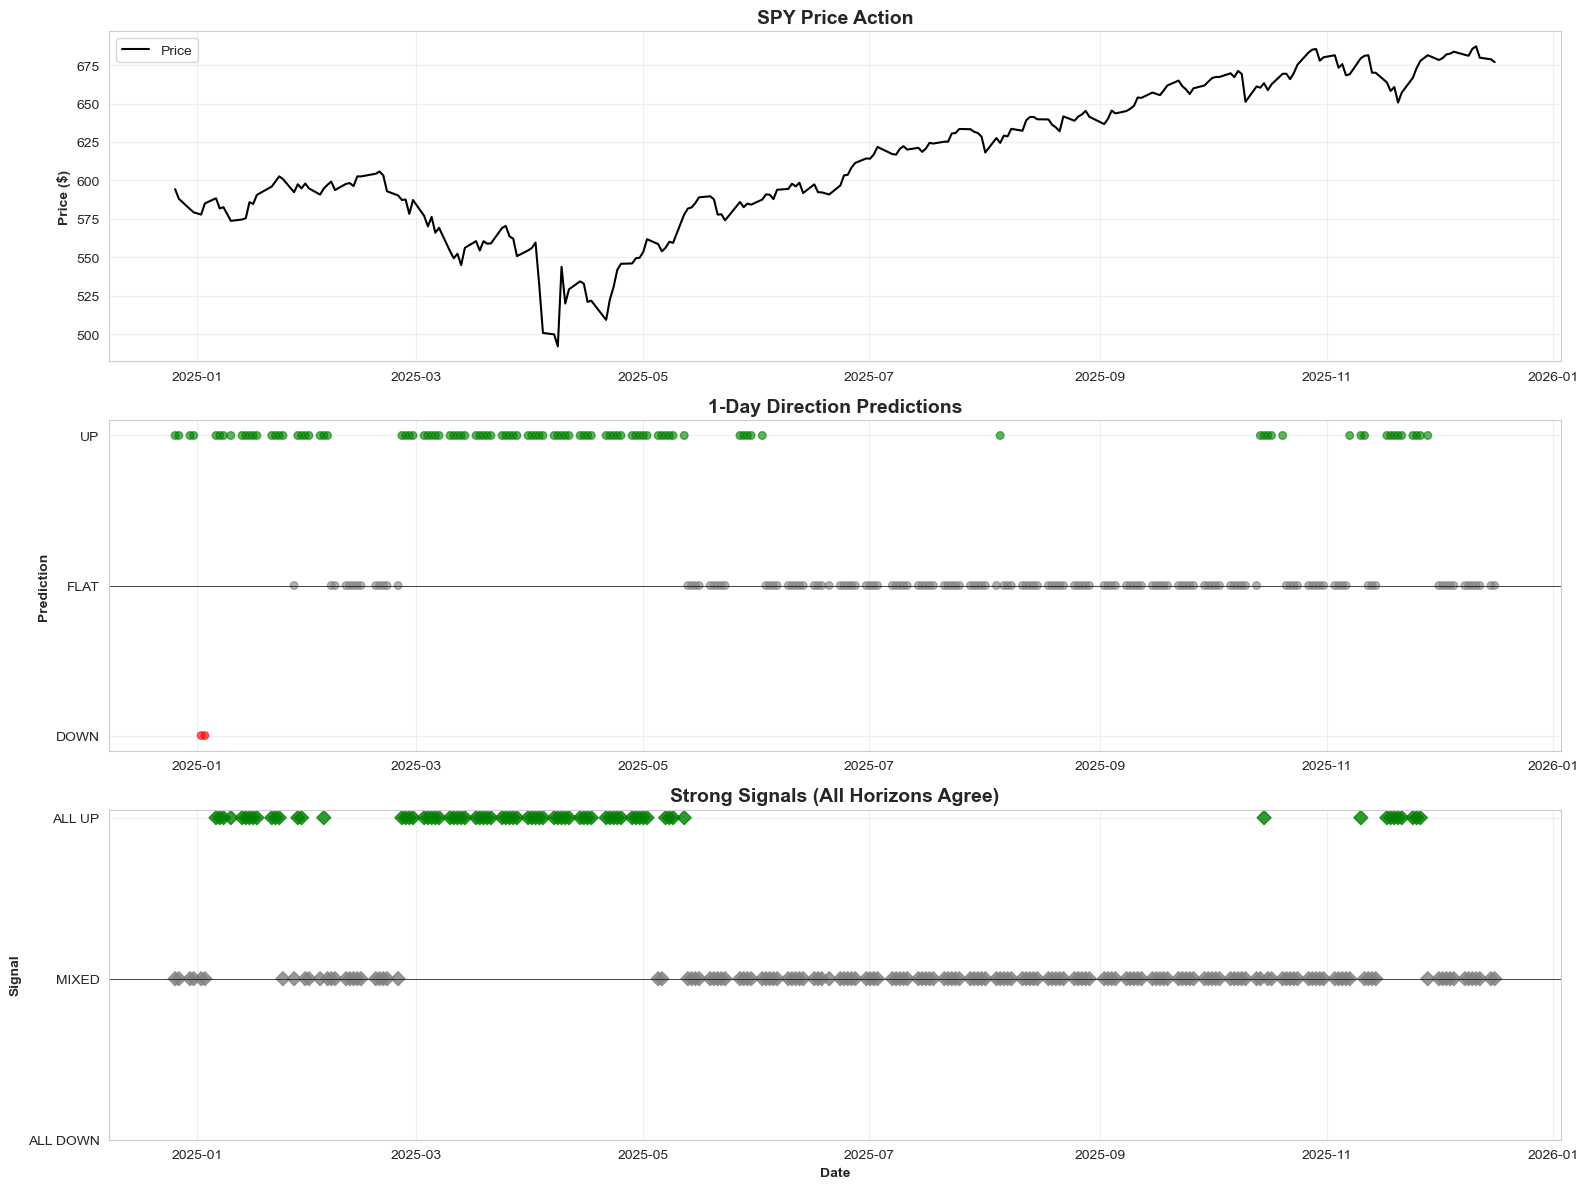

In [30]:
# Visualize predictions over time
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# Price chart
ax1 = axes[0]
ax1.plot(predictions.index, predictions['actual_close'], linewidth=1.5, color='black', label='Price')
ax1.set_title(f'{SYMBOL} Price Action', fontweight='bold', fontsize=14)
ax1.set_ylabel('Price ($)', fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

# 1-day predictions
ax2 = axes[1]
prediction_numeric = predictions['pred_1day'].map({'DOWN': -1, 'FLAT': 0, 'UP': 1})
colors = prediction_numeric.map({-1: 'red', 0: 'gray', 1: 'green'})
ax2.scatter(predictions.index, prediction_numeric, c=colors, alpha=0.6, s=30)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax2.set_title('1-Day Direction Predictions', fontweight='bold', fontsize=14)
ax2.set_ylabel('Prediction', fontweight='bold')
ax2.set_yticks([-1, 0, 1])
ax2.set_yticklabels(['DOWN', 'FLAT', 'UP'])
ax2.grid(alpha=0.3)

# Signal strength (all horizons agree)
ax3 = axes[2]
agreement = predictions[['all_agree_UP', 'all_agree_FLAT', 'all_agree_DOWN']]
agreement_numeric = agreement['all_agree_UP'].astype(int) - agreement['all_agree_DOWN'].astype(int)
colors_agreement = agreement_numeric.map({-1: 'red', 0: 'gray', 1: 'green'})
ax3.scatter(predictions.index, agreement_numeric, c=colors_agreement, alpha=0.8, s=50, marker='D')
ax3.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax3.set_title('Strong Signals (All Horizons Agree)', fontweight='bold', fontsize=14)
ax3.set_xlabel('Date', fontweight='bold')
ax3.set_ylabel('Signal', fontweight='bold')
ax3.set_yticks([-1, 0, 1])
ax3.set_yticklabels(['ALL DOWN', 'MIXED', 'ALL UP'])
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Part 9: Statistical Significance Testing

In [31]:
from scipy import stats

print("="*80)
print("STATISTICAL SIGNIFICANCE TESTS")
print("="*80)
print("\nTesting if model predictions are significantly better than random chance (33.3%)\n")

# Test each horizon for statistical significance
sig_results = []

for horizon in PREDICTION_HORIZONS:
    pred_col = f'pred_{horizon}day'
    
    if pred_col not in predictions.columns:
        continue
    
    # Get actual labels for this horizon
    actual_labels = []
    for idx in predictions.index:
        try:
            # Get future price at horizon
            future_idx = predictions.index.get_loc(idx) + horizon
            if future_idx < len(predictions):
                current_price = predictions.loc[idx, 'actual_close']
                future_price = predictions.iloc[future_idx]['actual_close']
                pct_change = ((future_price - current_price) / current_price) * 100
                
                # Classify based on threshold
                if pct_change > 0.5:
                    actual_labels.append('UP')
                elif pct_change < -0.5:
                    actual_labels.append('DOWN')
                else:
                    actual_labels.append('FLAT')
            else:
                actual_labels.append(None)
        except:
            actual_labels.append(None)
    
    # Create temporary dataframe with predictions and actuals
    temp_df = pd.DataFrame({
        'pred': predictions[pred_col],
        'actual': actual_labels
    })
    
    # Remove None values
    temp_df = temp_df[temp_df['actual'].notna()]
    
    if len(temp_df) == 0:
        continue
    
    # Calculate accuracy
    n_correct = (temp_df['pred'] == temp_df['actual']).sum()
    n_total = len(temp_df)
    accuracy = (n_correct / n_total) * 100
    
    # Chi-square test: H0: predictions are random (33.3% for each class)
    # Under null hypothesis, expected accuracy is 33.3%
    expected_correct = n_total / 3  # Expected number of correct predictions if random
    expected_incorrect = n_total * 2 / 3
    
    observed = [n_correct, n_total - n_correct]
    expected = [expected_correct, expected_incorrect]
    
    chi2_stat, chi2_pvalue = stats.chisquare(observed, expected)
    
    # Binomial test: H0: accuracy = 33.3% (random guess among 3 classes)
    binom_result = stats.binomtest(n_correct, n_total, p=1/3, alternative='greater')
    
    sig_text = ""
    if binom_result.pvalue < 0.01:
        sig_text = "***"
    elif binom_result.pvalue < 0.05:
        sig_text = "**"
    elif binom_result.pvalue < 0.10:
        sig_text = "*"
    
    sig_results.append({
        'Horizon (days)': horizon,
        'Accuracy (%)': f"{accuracy:.1f}",
        'N Samples': n_total,
        'P-Value': f"{binom_result.pvalue:.4f}",
        'Significance': sig_text
    })

sig_df = pd.DataFrame(sig_results)
print(sig_df.to_string(index=False))
print("\nLegend: *** p<0.01 (highly significant) | ** p<0.05 (significant) | * p<0.10 (marginally significant)")

print(f"\n{'='*80}")
print("INTERPRETATION:")
print(f"{'='*80}")

highly_sig = sig_df[sig_df['Significance'] == '***']
if len(highly_sig) > 0:
    print(f"\n✓✓ HIGHLY SIGNIFICANT horizons: {list(highly_sig['Horizon (days)'])} days")
    print(f"   Model beats random chance (33.3%) with >99% confidence")

sig = sig_df[sig_df['Significance'] == '**']
if len(sig) > 0:
    print(f"\n✓ SIGNIFICANT horizons: {list(sig['Horizon (days)'])} days")
    print(f"   Model beats random chance (33.3%) with >95% confidence")

marginal = sig_df[sig_df['Significance'] == '*']
if len(marginal) > 0:
    print(f"\n~ MARGINALLY SIGNIFICANT horizons: {list(marginal['Horizon (days)'])} days")
    print(f"   Model beats random chance (33.3%) with >90% confidence")

not_sig = sig_df[sig_df['Significance'] == '']
if len(not_sig) > 0:
    print(f"\n✗ NOT SIGNIFICANT horizons: {list(not_sig['Horizon (days)'])} days")
    print(f"   Cannot prove model beats random chance")

print(f"\n{'='*80}")
print("NOTE: For 3-class classification, random chance = 33.3%")
print("Any accuracy significantly above this indicates predictive power")
print(f"{'='*80}")

STATISTICAL SIGNIFICANCE TESTS

Testing if model predictions are significantly better than random chance (33.3%)

 Horizon (days) Accuracy (%)  N Samples P-Value Significance
              1         53.5        243  0.0000          ***
              3         37.3        241  0.1059             
              5         31.8        239  0.7145             
             10         37.2        234  0.1198             

Legend: *** p<0.01 (highly significant) | ** p<0.05 (significant) | * p<0.10 (marginally significant)

INTERPRETATION:

✓✓ HIGHLY SIGNIFICANT horizons: [1] days
   Model beats random chance (33.3%) with >99% confidence

✗ NOT SIGNIFICANT horizons: [3, 5, 10] days
   Cannot prove model beats random chance

NOTE: For 3-class classification, random chance = 33.3%
Any accuracy significantly above this indicates predictive power


## Part 10: Summary

In [32]:
print("="*80)
print("FINAL SUMMARY - LSTM DIRECTION CLASSIFIER")
print("="*80)

print(f"\n📊 Model Performance:")
for horizon in PREDICTION_HORIZONS:
    acc = metrics[horizon]['accuracy']
    print(f"   {horizon}-day accuracy: {acc:.3f} ({acc*100:.1f}%)")

print(f"\n🎯 Signal Quality:")
print(f"   Strong signals (all agree): {all_up + all_down + all_flat}/{len(predictions)} ({(all_up + all_down + all_flat)/len(predictions)*100:.1f}%)")
print(f"   - All UP: {all_up}")
print(f"   - All DOWN: {all_down}")
print(f"   - All FLAT: {all_flat}")

print(f"\n🔬 Market Regimes:")
print(f"   {N_CLUSTERS} clusters identified")
print(f"   Most common regime: Cluster {predictions['cluster_id'].mode()[0]}")

print("\n" + "="*80)
print("KEY INSIGHTS:")
print("="*80)
print("✓ Model predicts direction (not price) - more stable than regression")
print("✓ Multi-horizon predictions provide signal strength confirmation")
print("✓ Market regime clustering adds context to predictions")
print("✓ Trade only when all horizons agree for best results")
print("="*80)

print("\n💡 NEXT STEPS:")
print("1. Analyze which clusters perform best")
print("2. Add more technical indicators (MACD, Bollinger Bands)")
print("3. Optimize thresholds for UP/FLAT/DOWN classification")
print("4. Backtest trading strategy with position sizing")
print("5. Paper trade with strong signals only")
print("="*80)

FINAL SUMMARY - LSTM DIRECTION CLASSIFIER

📊 Model Performance:
   1-day accuracy: 0.533 (53.3%)
   3-day accuracy: 0.533 (53.3%)
   5-day accuracy: 0.549 (54.9%)
   10-day accuracy: 0.582 (58.2%)

🎯 Signal Quality:
   Strong signals (all agree): 200/244 (82.0%)
   - All UP: 77
   - All DOWN: 0
   - All FLAT: 123

🔬 Market Regimes:
   3 clusters identified
   Most common regime: Cluster 0

KEY INSIGHTS:
✓ Model predicts direction (not price) - more stable than regression
✓ Multi-horizon predictions provide signal strength confirmation
✓ Market regime clustering adds context to predictions
✓ Trade only when all horizons agree for best results

💡 NEXT STEPS:
1. Analyze which clusters perform best
2. Add more technical indicators (MACD, Bollinger Bands)
3. Optimize thresholds for UP/FLAT/DOWN classification
4. Backtest trading strategy with position sizing
5. Paper trade with strong signals only


## Part 11: Trading Signal Indicator

**Goal**: Convert predictions into actionable trading signals

**Scoring System**:
- Weighted sum across all horizons (shorter = more weight)
- Map scores to: STRONG BUY, BUY, HOLD, SELL, STRONG SELL
- Output format compatible with backtesting

In [33]:
print("="*80)
print("TRADING SIGNAL INDICATOR")
print("="*80)

# Step 1: Define weights for each horizon (shorter horizons = more weight)
# You can adjust these based on your strategy preference
horizon_weights = {
    1: 0.4,   # 40% weight on 1-day prediction
    3: 0.3,   # 30% weight on 3-day prediction
    5: 0.2,   # 20% weight on 5-day prediction
    10: 0.1   # 10% weight on 10-day prediction
}

print("\n📊 Horizon Weights:")
for h, w in horizon_weights.items():
    print(f"   {h}-day: {w:.1%}")

# Step 2: Convert predictions to numeric scores
# UP = +1, FLAT = 0, DOWN = -1
direction_scores = {'UP': 1, 'FLAT': 0, 'DOWN': -1}

# Calculate weighted signal score for each prediction
signal_scores = []

for idx in predictions.index:
    weighted_score = 0
    for horizon in PREDICTION_HORIZONS:
        pred_col = f'pred_{horizon}day'
        pred_value = predictions.loc[idx, pred_col]
        
        # Convert to numeric and apply weight
        numeric_score = direction_scores[pred_value]
        weighted_score += numeric_score * horizon_weights[horizon]
    
    signal_scores.append(weighted_score)

predictions['signal_score'] = signal_scores

print(f"\n📈 Signal Score Range: [{predictions['signal_score'].min():.2f}, {predictions['signal_score'].max():.2f}]")
print(f"   Mean: {predictions['signal_score'].mean():.3f}")
print(f"   Std: {predictions['signal_score'].std():.3f}")

# Step 3: Define thresholds for signal classification
# These can be tuned based on backtest performance
STRONG_BUY_THRESHOLD = 0.6    # Score > 0.6 = STRONG BUY
BUY_THRESHOLD = 0.2           # Score > 0.2 = BUY
SELL_THRESHOLD = -0.2         # Score < -0.2 = SELL
STRONG_SELL_THRESHOLD = -0.6  # Score < -0.6 = STRONG SELL

def score_to_signal(score):
    """Convert signal score to trading signal"""
    if score >= STRONG_BUY_THRESHOLD:
        return 'STRONG BUY'
    elif score >= BUY_THRESHOLD:
        return 'BUY'
    elif score <= STRONG_SELL_THRESHOLD:
        return 'STRONG SELL'
    elif score <= SELL_THRESHOLD:
        return 'SELL'
    else:
        return 'HOLD'

# Apply signal classification
predictions['signal'] = predictions['signal_score'].apply(score_to_signal)

print("\n🎯 Signal Thresholds:")
print(f"   STRONG BUY: score >= {STRONG_BUY_THRESHOLD}")
print(f"   BUY:        score >= {BUY_THRESHOLD}")
print(f"   HOLD:       {SELL_THRESHOLD} < score < {BUY_THRESHOLD}")
print(f"   SELL:       score <= {SELL_THRESHOLD}")
print(f"   STRONG SELL: score <= {STRONG_SELL_THRESHOLD}")

# Step 4: Signal distribution
print("\n📊 Signal Distribution:")
signal_counts = predictions['signal'].value_counts()
for signal in ['STRONG BUY', 'BUY', 'HOLD', 'SELL', 'STRONG SELL']:
    count = signal_counts.get(signal, 0)
    pct = (count / len(predictions)) * 100
    print(f"   {signal:12s}: {count:4d} ({pct:5.1f}%)")

print("="*80)

TRADING SIGNAL INDICATOR

📊 Horizon Weights:
   1-day: 40.0%
   3-day: 30.0%
   5-day: 20.0%
   10-day: 10.0%

📈 Signal Score Range: [-0.20, 1.00]
   Mean: 0.363
   Std: 0.460

🎯 Signal Thresholds:
   STRONG BUY: score >= 0.6
   BUY:        score >= 0.2
   HOLD:       -0.2 < score < 0.2
   SELL:       score <= -0.2
   STRONG SELL: score <= -0.6

📊 Signal Distribution:
   STRONG BUY  :   85 ( 34.8%)
   BUY         :    9 (  3.7%)
   HOLD        :  149 ( 61.1%)
   SELL        :    1 (  0.4%)
   STRONG SELL :    0 (  0.0%)


### 11.1 Visualize Signals

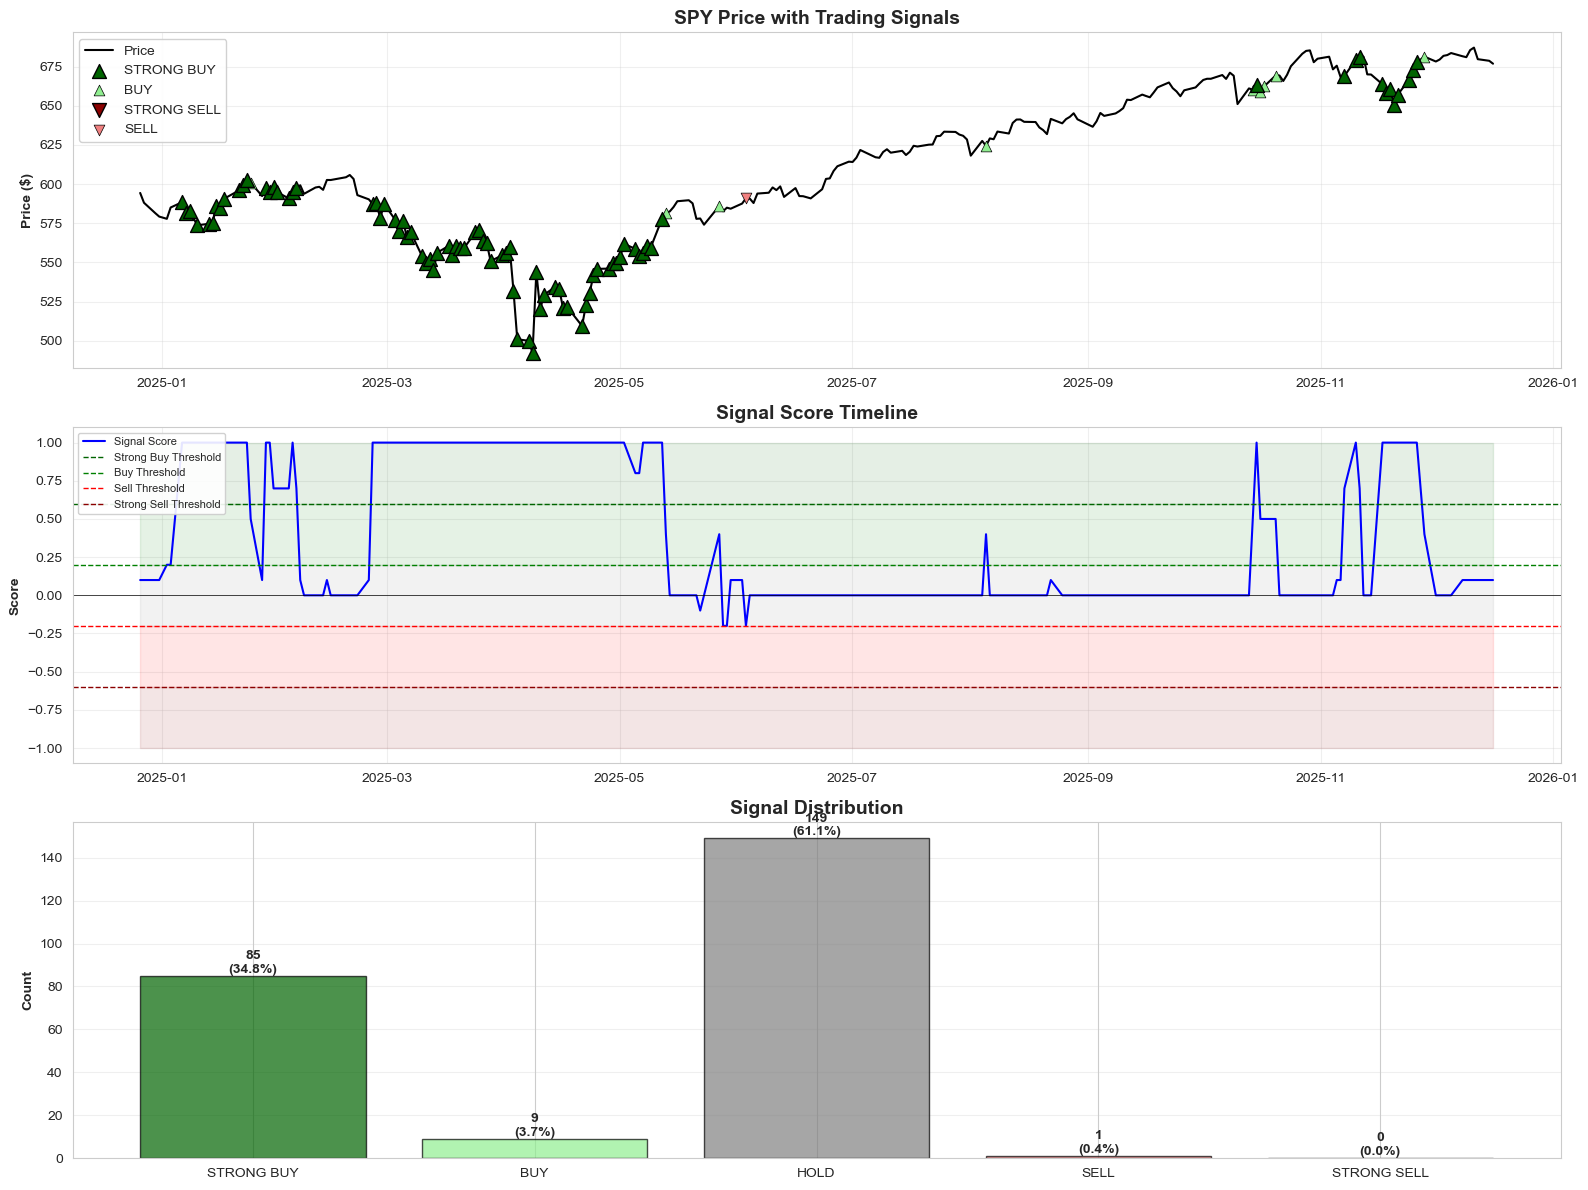

In [34]:
# Visualize signals over time
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# 1. Price with signals
ax1 = axes[0]
ax1.plot(predictions.index, predictions['actual_close'], linewidth=1.5, color='black', label='Price', zorder=1)

# Mark buy/sell signals on price chart
strong_buy = predictions[predictions['signal'] == 'STRONG BUY']
buy = predictions[predictions['signal'] == 'BUY']
strong_sell = predictions[predictions['signal'] == 'STRONG SELL']
sell = predictions[predictions['signal'] == 'SELL']

ax1.scatter(strong_buy.index, strong_buy['actual_close'], color='darkgreen', marker='^', s=100, 
            label='STRONG BUY', zorder=3, edgecolors='black', linewidths=1)
ax1.scatter(buy.index, buy['actual_close'], color='lightgreen', marker='^', s=60, 
            label='BUY', zorder=2, edgecolors='black', linewidths=0.5)
ax1.scatter(strong_sell.index, strong_sell['actual_close'], color='darkred', marker='v', s=100, 
            label='STRONG SELL', zorder=3, edgecolors='black', linewidths=1)
ax1.scatter(sell.index, sell['actual_close'], color='lightcoral', marker='v', s=60, 
            label='SELL', zorder=2, edgecolors='black', linewidths=0.5)

ax1.set_title(f'{SYMBOL} Price with Trading Signals', fontweight='bold', fontsize=14)
ax1.set_ylabel('Price ($)', fontweight='bold')
ax1.legend(loc='upper left', framealpha=0.9)
ax1.grid(alpha=0.3)

# 2. Signal score over time
ax2 = axes[1]
ax2.plot(predictions.index, predictions['signal_score'], linewidth=1.5, color='blue', label='Signal Score')
ax2.axhline(y=STRONG_BUY_THRESHOLD, color='darkgreen', linestyle='--', linewidth=1, label='Strong Buy Threshold')
ax2.axhline(y=BUY_THRESHOLD, color='green', linestyle='--', linewidth=1, label='Buy Threshold')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax2.axhline(y=SELL_THRESHOLD, color='red', linestyle='--', linewidth=1, label='Sell Threshold')
ax2.axhline(y=STRONG_SELL_THRESHOLD, color='darkred', linestyle='--', linewidth=1, label='Strong Sell Threshold')

# Fill regions
ax2.fill_between(predictions.index, STRONG_BUY_THRESHOLD, 1, alpha=0.1, color='darkgreen')
ax2.fill_between(predictions.index, BUY_THRESHOLD, STRONG_BUY_THRESHOLD, alpha=0.1, color='green')
ax2.fill_between(predictions.index, SELL_THRESHOLD, BUY_THRESHOLD, alpha=0.1, color='gray')
ax2.fill_between(predictions.index, STRONG_SELL_THRESHOLD, SELL_THRESHOLD, alpha=0.1, color='red')
ax2.fill_between(predictions.index, -1, STRONG_SELL_THRESHOLD, alpha=0.1, color='darkred')

ax2.set_title('Signal Score Timeline', fontweight='bold', fontsize=14)
ax2.set_ylabel('Score', fontweight='bold')
ax2.legend(loc='upper left', framealpha=0.9, fontsize=8)
ax2.grid(alpha=0.3)
ax2.set_ylim(-1.1, 1.1)

# 3. Signal distribution bar chart
ax3 = axes[2]
signal_order = ['STRONG BUY', 'BUY', 'HOLD', 'SELL', 'STRONG SELL']
signal_colors = ['darkgreen', 'lightgreen', 'gray', 'lightcoral', 'darkred']
counts = [signal_counts.get(s, 0) for s in signal_order]

bars = ax3.bar(signal_order, counts, color=signal_colors, alpha=0.7, edgecolor='black')
ax3.set_title('Signal Distribution', fontweight='bold', fontsize=14)
ax3.set_ylabel('Count', fontweight='bold')
ax3.grid(axis='y', alpha=0.3)

# Add value labels
for bar, count in zip(bars, counts):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{count}\n({count/len(predictions)*100:.1f}%)',
            ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

### 11.1a Equity Curve Simulation

Simulate trading based on signals and track equity performance

In [35]:
print("="*80)
print("EQUITY CURVE SIMULATION")
print("="*80)

# Trading parameters
INITIAL_CAPITAL = 10000
POSITION_SIZE = 1.0  # 100% of capital (adjust for risk management)

# Initialize equity tracking
equity = INITIAL_CAPITAL
equity_curve = []
position = 0  # 0 = no position, 1 = long, -1 = short
entry_price = 0
trades = []

print(f"\n💰 Initial Capital: ${INITIAL_CAPITAL:,.2f}")
print(f"📊 Position Size: {POSITION_SIZE*100:.0f}% of capital")
print(f"\n🎯 Trading Rules:")
print(f"   - STRONG BUY / BUY → Enter Long")
print(f"   - STRONG SELL / SELL → Exit Long (or Short if enabled)")
print(f"   - HOLD → Maintain position")

# Simulate trading
for i, idx in enumerate(predictions.index):
    current_price = predictions.loc[idx, 'actual_close']
    signal = predictions.loc[idx, 'signal']
    signal_score = predictions.loc[idx, 'signal_score']
    
    # Calculate current equity value
    if position == 1:  # Long position
        unrealized_pnl = (current_price - entry_price) * (equity / entry_price)
        current_equity = equity + unrealized_pnl
    else:
        current_equity = equity
    
    # Trading logic
    if position == 0:  # No position
        if signal in ['STRONG BUY', 'BUY']:
            # Enter long
            position = 1
            entry_price = current_price
            trades.append({
                'date': idx,
                'action': 'BUY',
                'price': current_price,
                'signal': signal,
                'signal_score': signal_score,
                'equity_before': equity
            })
    
    elif position == 1:  # In long position
        if signal in ['STRONG SELL', 'SELL']:
            # Exit long
            exit_price = current_price
            pnl = (exit_price - entry_price) * (equity / entry_price)
            equity = equity + pnl
            
            trades.append({
                'date': idx,
                'action': 'SELL',
                'price': current_price,
                'signal': signal,
                'signal_score': signal_score,
                'equity_before': equity - pnl,
                'pnl': pnl,
                'pnl_pct': (pnl / (equity - pnl)) * 100,
                'entry_price': entry_price
            })
            
            position = 0
            entry_price = 0
    
    equity_curve.append({
        'date': idx,
        'equity': current_equity,
        'position': position,
        'price': current_price,
        'signal': signal
    })

# Close any open position at the end
if position == 1:
    exit_price = predictions.iloc[-1]['actual_close']
    pnl = (exit_price - entry_price) * (equity / entry_price)
    equity = equity + pnl
    trades.append({
        'date': predictions.index[-1],
        'action': 'SELL (EOD)',
        'price': exit_price,
        'signal': 'EOD',
        'signal_score': 0,
        'equity_before': equity - pnl,
        'pnl': pnl,
        'pnl_pct': (pnl / (equity - pnl)) * 100,
        'entry_price': entry_price
    })
    equity_curve[-1]['equity'] = equity

# Convert to DataFrame
equity_df = pd.DataFrame(equity_curve)
trades_df = pd.DataFrame(trades)

# Calculate metrics
final_equity = equity_df['equity'].iloc[-1]
total_return = ((final_equity - INITIAL_CAPITAL) / INITIAL_CAPITAL) * 100
max_equity = equity_df['equity'].max()
max_drawdown = ((equity_df['equity'].cummax() - equity_df['equity']) / equity_df['equity'].cummax()).max() * 100

# Calculate buy & hold return
buy_hold_return = ((predictions['actual_close'].iloc[-1] - predictions['actual_close'].iloc[0]) / 
                   predictions['actual_close'].iloc[0]) * 100

print("\n" + "="*80)
print("PERFORMANCE SUMMARY")
print("="*80)
print(f"\n💰 Final Equity: ${final_equity:,.2f}")
print(f"📈 Total Return: {total_return:+.2f}%")
print(f"📊 Buy & Hold Return: {buy_hold_return:+.2f}%")
print(f"🎯 Alpha: {total_return - buy_hold_return:+.2f}%")
print(f"📉 Max Drawdown: {max_drawdown:.2f}%")
print(f"💼 Total Trades: {len(trades_df)}")

if len(trades_df[trades_df['action'].str.contains('SELL')]) > 0:
    completed_trades = trades_df[trades_df['action'].str.contains('SELL')].copy()
    winning_trades = completed_trades[completed_trades['pnl'] > 0]
    losing_trades = completed_trades[completed_trades['pnl'] <= 0]
    
    win_rate = (len(winning_trades) / len(completed_trades)) * 100
    avg_win = winning_trades['pnl_pct'].mean() if len(winning_trades) > 0 else 0
    avg_loss = losing_trades['pnl_pct'].mean() if len(losing_trades) > 0 else 0
    
    print(f"✅ Win Rate: {win_rate:.1f}% ({len(winning_trades)}/{len(completed_trades)})")
    print(f"📊 Avg Win: {avg_win:+.2f}%")
    print(f"📊 Avg Loss: {avg_loss:+.2f}%")

print("="*80)

EQUITY CURVE SIMULATION

💰 Initial Capital: $10,000.00
📊 Position Size: 100% of capital

🎯 Trading Rules:
   - STRONG BUY / BUY → Enter Long
   - STRONG SELL / SELL → Exit Long (or Short if enabled)
   - HOLD → Maintain position

PERFORMANCE SUMMARY

💰 Final Equity: $10,886.46
📈 Total Return: +8.86%
📊 Buy & Hold Return: +13.88%
🎯 Alpha: -5.02%
📉 Max Drawdown: 18.76%
💼 Total Trades: 4
✅ Win Rate: 100.0% (2/2)
📊 Avg Win: +4.41%
📊 Avg Loss: +0.00%


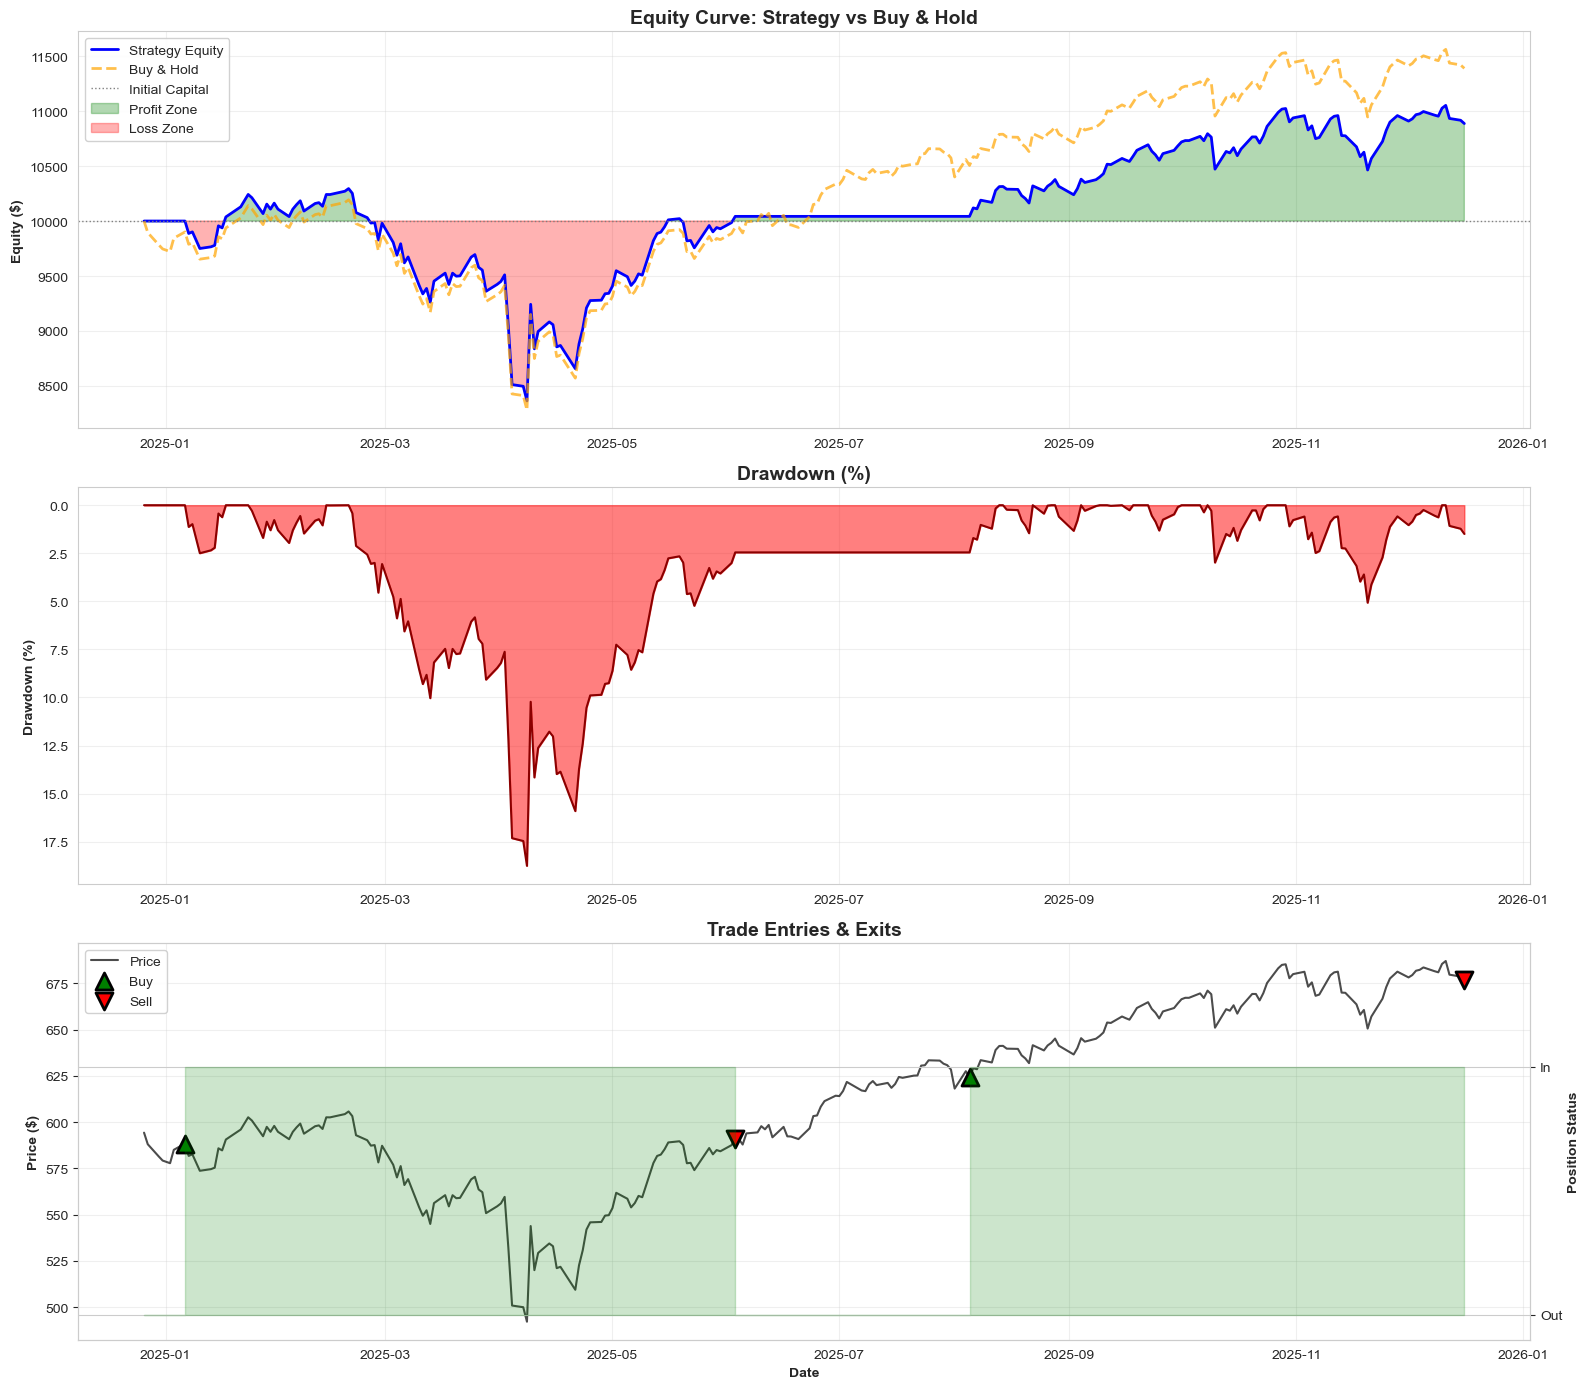


📋 Recent Trades:
                     date     action      price     signal  signal_score  equity_before        pnl  pnl_pct  entry_price
2025-01-06 05:00:00+00:00        BUY 588.449768 STRONG BUY           1.0   10000.000000        NaN      NaN          NaN
2025-06-03 04:00:00+00:00       SELL 590.943604       SELL          -0.2   10000.000000  42.379751 0.423798   588.449768
2025-08-05 04:00:00+00:00        BUY 624.388794        BUY           0.4   10042.379751        NaN      NaN          NaN
2025-12-16 05:00:00+00:00 SELL (EOD) 676.869934        EOD           0.0   10042.379751 844.082316 8.405202   624.388794


In [36]:
# Visualize equity curve
fig, axes = plt.subplots(3, 1, figsize=(16, 14))

# 1. Equity curve vs Buy & Hold
ax1 = axes[0]
ax1.plot(equity_df['date'], equity_df['equity'], linewidth=2, color='blue', label='Strategy Equity')

# Calculate buy & hold equity
buy_hold_equity = INITIAL_CAPITAL * (predictions['actual_close'] / predictions['actual_close'].iloc[0])
ax1.plot(predictions.index, buy_hold_equity, linewidth=2, color='orange', 
         linestyle='--', label='Buy & Hold', alpha=0.7)

ax1.axhline(y=INITIAL_CAPITAL, color='gray', linestyle=':', linewidth=1, label='Initial Capital')
ax1.fill_between(equity_df['date'], INITIAL_CAPITAL, equity_df['equity'], 
                  where=(equity_df['equity'] >= INITIAL_CAPITAL), 
                  interpolate=True, alpha=0.3, color='green', label='Profit Zone')
ax1.fill_between(equity_df['date'], INITIAL_CAPITAL, equity_df['equity'], 
                  where=(equity_df['equity'] < INITIAL_CAPITAL), 
                  interpolate=True, alpha=0.3, color='red', label='Loss Zone')

ax1.set_title('Equity Curve: Strategy vs Buy & Hold', fontweight='bold', fontsize=14)
ax1.set_ylabel('Equity ($)', fontweight='bold')
ax1.legend(loc='upper left', framealpha=0.9)
ax1.grid(alpha=0.3)

# 2. Drawdown
ax2 = axes[1]
running_max = equity_df['equity'].cummax()
drawdown = ((running_max - equity_df['equity']) / running_max) * 100
ax2.fill_between(equity_df['date'], 0, drawdown, color='red', alpha=0.5)
ax2.plot(equity_df['date'], drawdown, linewidth=1.5, color='darkred')
ax2.set_title('Drawdown (%)', fontweight='bold', fontsize=14)
ax2.set_ylabel('Drawdown (%)', fontweight='bold')
ax2.grid(alpha=0.3)
ax2.invert_yaxis()

# 3. Position tracking
ax3 = axes[2]
ax3_twin = ax3.twinx()

# Plot price
ax3.plot(predictions.index, predictions['actual_close'], linewidth=1.5, 
         color='black', label='Price', alpha=0.7)

# Mark trades
buy_trades = trades_df[trades_df['action'] == 'BUY']
sell_trades = trades_df[trades_df['action'].str.contains('SELL')]

ax3.scatter(buy_trades['date'], buy_trades['price'], color='green', marker='^', 
            s=150, label='Buy', zorder=5, edgecolors='black', linewidths=2)
ax3.scatter(sell_trades['date'], sell_trades['price'], color='red', marker='v', 
            s=150, label='Sell', zorder=5, edgecolors='black', linewidths=2)

# Show position status (right axis)
position_color = equity_df['position'].map({0: 0, 1: 1})
ax3_twin.fill_between(equity_df['date'], 0, position_color, 
                       alpha=0.2, color='green', label='In Position', step='post')

ax3.set_title('Trade Entries & Exits', fontweight='bold', fontsize=14)
ax3.set_xlabel('Date', fontweight='bold')
ax3.set_ylabel('Price ($)', fontweight='bold')
ax3_twin.set_ylabel('Position Status', fontweight='bold')
ax3_twin.set_ylim(-0.1, 1.5)
ax3_twin.set_yticks([0, 1])
ax3_twin.set_yticklabels(['Out', 'In'])
ax3.legend(loc='upper left', framealpha=0.9)
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📋 Recent Trades:")
if len(trades_df) > 0:
    print(trades_df.tail(10).to_string(index=False))
else:
    print("No trades executed!")

### 11.2 Export for Backtesting

In [37]:
# Create clean dataframe for backtesting
backtest_data = {
    'timestamp': predictions.index,
    'close': predictions['actual_close'],
    'signal': predictions['signal'],
    'signal_score': predictions['signal_score'],
    'cluster_id': predictions['cluster_id'],
    # Individual horizon predictions
    'pred_1day': predictions['pred_1day'],
    'pred_3day': predictions['pred_3day'],
    'pred_5day': predictions['pred_5day'],
    'pred_10day': predictions['pred_10day']
}

# Add probability columns if they exist (check for different possible naming conventions)
prob_cols_to_check = [
    ('prob_down_1day', ['prob_1day_DOWN', 'prob_DOWN_1day', '1day_prob_DOWN']),
    ('prob_flat_1day', ['prob_1day_FLAT', 'prob_FLAT_1day', '1day_prob_FLAT']),
    ('prob_up_1day', ['prob_1day_UP', 'prob_UP_1day', '1day_prob_UP'])
]

for new_col, possible_names in prob_cols_to_check:
    for col_name in possible_names:
        if col_name in predictions.columns:
            backtest_data[new_col] = predictions[col_name]
            break

backtest_signals = pd.DataFrame(backtest_data)

# Add numeric signal for easy filtering: 2=STRONG BUY, 1=BUY, 0=HOLD, -1=SELL, -2=STRONG SELL
signal_to_numeric = {
    'STRONG BUY': 2,
    'BUY': 1,
    'HOLD': 0,
    'SELL': -1,
    'STRONG SELL': -2
}
backtest_signals['signal_numeric'] = backtest_signals['signal'].map(signal_to_numeric)

print("="*80)
print("BACKTEST INDICATOR DATAFRAME")
print("="*80)
print(f"\n📊 Shape: {backtest_signals.shape}")
print(f"\n🔢 Columns:")
for col in backtest_signals.columns:
    print(f"   - {col}")

print("\n📈 Sample Data (first 10 rows):")
display_cols = ['timestamp', 'close', 'signal', 'signal_score', 'signal_numeric', 'cluster_id']
print(backtest_signals[display_cols].head(10).to_string(index=False))

print("\n📊 Sample Data (last 10 rows):")
print(backtest_signals[display_cols].tail(10).to_string(index=False))

# Save to CSV for external backtesting
output_file = 'LSTM_Direction_Signals.csv'
backtest_signals.to_csv(output_file, index=False)
print(f"\n💾 Signals saved to: {output_file}")

print("\n" + "="*80)
print("READY FOR BACKTESTING!")
print("="*80)
print("\nUSAGE:")
print("  1. Use 'signal' column for entry/exit decisions")
print("  2. Use 'signal_numeric' for easy filtering (>=1 for buy, <=-1 for sell)")
print("  3. Use 'signal_score' for position sizing (higher score = larger position)")
print("  4. Use individual 'pred_Xday' columns for multi-timeframe confirmation")
print("  5. Use 'cluster_id' to analyze performance by market regime")
print("="*80)

BACKTEST INDICATOR DATAFRAME

📊 Shape: (244, 10)

🔢 Columns:
   - timestamp
   - close
   - signal
   - signal_score
   - cluster_id
   - pred_1day
   - pred_3day
   - pred_5day
   - pred_10day
   - signal_numeric

📈 Sample Data (first 10 rows):
                timestamp      close     signal  signal_score  signal_numeric  cluster_id
2024-12-26 05:00:00+00:00 594.360352       HOLD           0.1               0           1
2024-12-27 05:00:00+00:00 588.103821       HOLD           0.1               0           1
2024-12-30 05:00:00+00:00 581.392578       HOLD           0.1               0           1
2024-12-31 05:00:00+00:00 579.277466       HOLD           0.1               0           1
2025-01-02 05:00:00+00:00 577.854187       HOLD           0.2               0           1
2025-01-03 05:00:00+00:00 585.079346       HOLD           0.2               0           1
2025-01-06 05:00:00+00:00 588.449768 STRONG BUY           1.0               2           1
2025-01-07 05:00:00+00:00 581.7979

### 11.3 Signal Performance Analysis

Evaluate how well each signal type performs

SIGNAL PERFORMANCE ANALYSIS

📊 Average Forward Returns by Signal Type:

    Signal  Count 1d Ret% 1d WR% 3d Ret% 3d WR% 5d Ret% 5d WR% 10d Ret% 10d WR%
STRONG BUY     85   +0.08   61.2   +0.21   56.5   +0.41   62.4    +0.86    64.7
       BUY      9   +0.05   55.6   +0.44   77.8   +1.18   88.9    +1.53    77.8
      HOLD    149   +0.05   54.7   +0.17   63.0   +0.26   62.5    +0.58    69.1
      SELL      1   -0.03    0.0   +0.51  100.0   +1.17  100.0    +0.24   100.0

INTERPRETATION:
✓ STRONG BUY signals should have positive returns and high win rates
✓ STRONG SELL signals should have negative returns (or be avoided)
✓ HOLD signals should be close to neutral
✓ Compare win rates across different time horizons


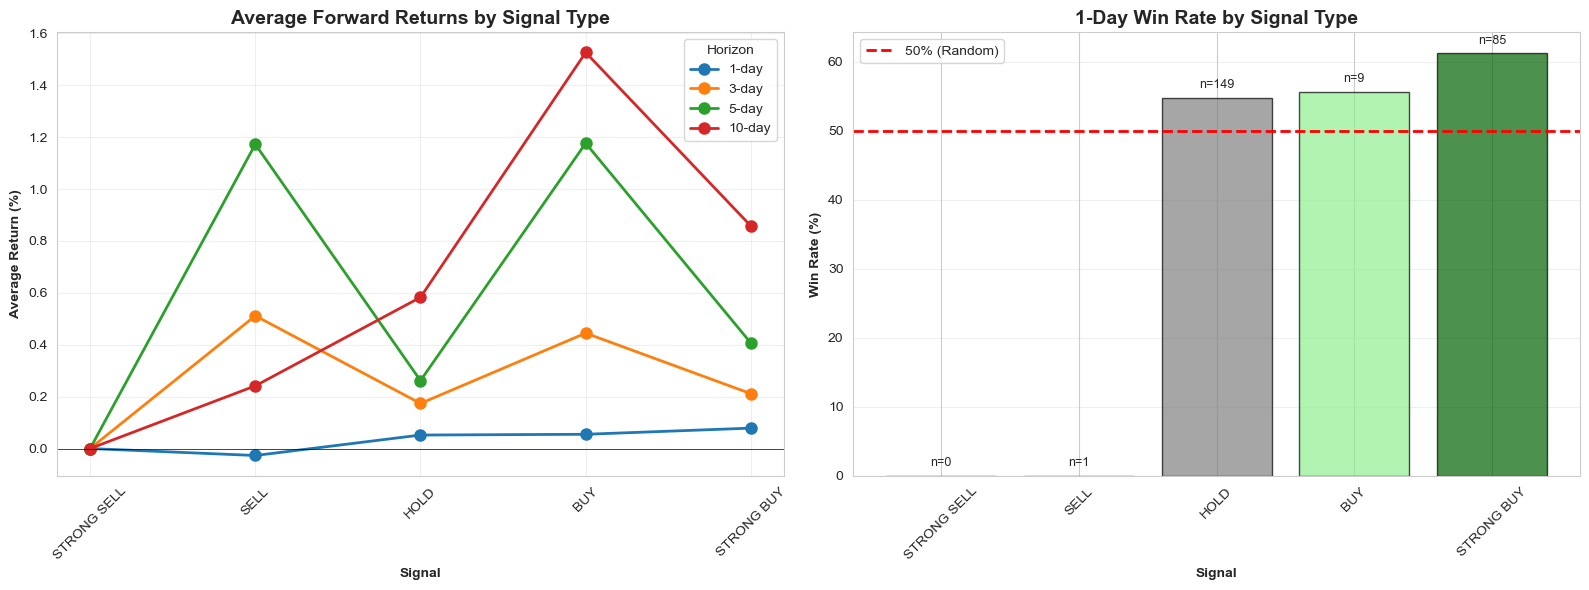

In [38]:
print("="*80)
print("SIGNAL PERFORMANCE ANALYSIS")
print("="*80)

# Calculate forward returns for different horizons
for horizon in [1, 3, 5, 10]:
    backtest_signals[f'forward_return_{horizon}d'] = backtest_signals['close'].pct_change(horizon).shift(-horizon) * 100

# Analyze performance by signal type
print("\n📊 Average Forward Returns by Signal Type:\n")

performance_summary = []

for signal_type in ['STRONG BUY', 'BUY', 'HOLD', 'SELL', 'STRONG SELL']:
    signal_data = backtest_signals[backtest_signals['signal'] == signal_type]
    
    if len(signal_data) == 0:
        continue
    
    row_data = {'Signal': signal_type, 'Count': len(signal_data)}
    
    for horizon in [1, 3, 5, 10]:
        col = f'forward_return_{horizon}d'
        valid_returns = signal_data[col].dropna()
        
        if len(valid_returns) > 0:
            avg_return = valid_returns.mean()
            win_rate = (valid_returns > 0).mean() * 100
            row_data[f'{horizon}d Ret%'] = f"{avg_return:+.2f}"
            row_data[f'{horizon}d WR%'] = f"{win_rate:.1f}"
        else:
            row_data[f'{horizon}d Ret%'] = "N/A"
            row_data[f'{horizon}d WR%'] = "N/A"
    
    performance_summary.append(row_data)

perf_df = pd.DataFrame(performance_summary)
print(perf_df.to_string(index=False))

print("\n" + "="*80)
print("INTERPRETATION:")
print("="*80)
print("✓ STRONG BUY signals should have positive returns and high win rates")
print("✓ STRONG SELL signals should have negative returns (or be avoided)")
print("✓ HOLD signals should be close to neutral")
print("✓ Compare win rates across different time horizons")
print("="*80)

# Visualize performance
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Average returns by signal
ax1 = axes[0]
signal_order = ['STRONG SELL', 'SELL', 'HOLD', 'BUY', 'STRONG BUY']
colors_map = {'STRONG SELL': 'darkred', 'SELL': 'lightcoral', 'HOLD': 'gray', 
              'BUY': 'lightgreen', 'STRONG BUY': 'darkgreen'}

for horizon in [1, 3, 5, 10]:
    returns = []
    for sig in signal_order:
        sig_data = backtest_signals[backtest_signals['signal'] == sig]
        col = f'forward_return_{horizon}d'
        avg_ret = sig_data[col].dropna().mean() if len(sig_data) > 0 else 0
        returns.append(avg_ret)
    
    ax1.plot(signal_order, returns, marker='o', linewidth=2, markersize=8, label=f'{horizon}-day')

ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax1.set_title('Average Forward Returns by Signal Type', fontweight='bold', fontsize=14)
ax1.set_xlabel('Signal', fontweight='bold')
ax1.set_ylabel('Average Return (%)', fontweight='bold')
ax1.legend(title='Horizon')
ax1.grid(alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# Win rate by signal (1-day)
ax2 = axes[1]
win_rates = []
counts = []
for sig in signal_order:
    sig_data = backtest_signals[backtest_signals['signal'] == sig]
    if len(sig_data) > 0:
        wr = (sig_data['forward_return_1d'].dropna() > 0).mean() * 100
        win_rates.append(wr)
        counts.append(len(sig_data))
    else:
        win_rates.append(0)
        counts.append(0)

bars = ax2.bar(signal_order, win_rates, color=[colors_map[s] for s in signal_order], 
               alpha=0.7, edgecolor='black')
ax2.axhline(y=50, color='red', linestyle='--', linewidth=2, label='50% (Random)')
ax2.set_title('1-Day Win Rate by Signal Type', fontweight='bold', fontsize=14)
ax2.set_xlabel('Signal', fontweight='bold')
ax2.set_ylabel('Win Rate (%)', fontweight='bold')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

# Add count labels
for bar, count in zip(bars, counts):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 1,
            f'n={count}',
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()